# Multi Agents - 자율 연구 에이전트
LangGraph를 활용하여 동적 워크플로우, 루프/재귀, Human-in-the-loop 패턴을 구현하는 자율 연구 시스템을 만듭니다.

## Autonomous Agent란?

**Autonomous Agent**는 **높은 자율성**을 가지고 동적으로 의사결정하며 작업하는 가장 고급 형태의 Multi-Agent 패턴입니다.

### 핵심 특징

1. **자율적 의사결정** (Autonomous Decision-Making)
   - 미리 정해진 경로가 아닌, 상황에 따라 스스로 판단
   - 목표 달성을 위한 최적의 경로 선택
   
2. **동적 워크플로우** (Dynamic Workflow)
   - 실행 중에 워크플로우가 변경됨
   - 조건에 따라 에이전트를 건너뛰거나 반복
   
3. **루프와 재귀** (Loop & Recursion)
   - 목표 달성까지 작업 반복
   - 결과가 만족스럽지 않으면 다시 시도
   
4. **Human-in-the-Loop (HITL)**
   - 중요한 결정에 사용자 개입
   - 사람의 판단과 AI의 자동화 결합

5. **메타인지** (Meta-cognition)
   - 자신의 작업을 평가하고 개선
   - "이 결과가 충분한가?" 스스로 판단

### 작동 방식

```
시작
  ↓
계획 수립 (Planning)
  ↓
작업 실행
  ↓
결과 검증 (Self-evaluation)
  ↓
만족스러운가?
  ├─ Yes → 완료
  └─ No → 추가 작업 필요
         ↓
      다시 계획 (Loop) 
         ↓
      반복...
```

### vs. 다른 패턴

| 패턴 | 워크플로우 | 자율성 | 반복 | 복잡도 |
|------|-----------|-------|------|--------|
| **Hierarchical** | 고정 | 낮음 | ❌ | ⭐ |
| **Sequential** | 고정 | 낮음 | ❌ | ⭐⭐ |
| **Collaborative** | 고정 | 중간 | ❌ | ⭐⭐⭐ |
| **Supervisor** | 반고정 | 중간 | △ | ⭐⭐⭐⭐ |
| **Autonomous** | **동적** | **높음** | **✅** | **⭐⭐⭐⭐⭐** |

### 이 예제가 Autonomous Agent인 이유

**자율 연구 에이전트**는 Autonomous Agent의 모든 특징을 보여줍니다:

#### 1. 자율적 의사결정
- **계획 에이전트**: 연구 주제를 스스로 분석하고 계획 수립
- **조정 에이전트**: "정보가 충분한가?" 스스로 판단
  - 부족하면 → 다시 검색
  - 충분하면 → 보고서 작성

#### 2. 동적 워크플로우
```
계획 → 검색 → 분석 → 검증
                    ↓
              충분한가?
            No ↓      ↓ Yes
            검색으로   보고서
            다시 ←
```
- 미리 정해진 것이 아님
- 검증 결과에 따라 경로 변경

#### 3. 루프와 재귀
- 정보가 부족하면 검색-분석-검증을 **반복**
- 최대 N회까지 반복 (무한 루프 방지)
- 각 반복마다 개선됨

#### 4. Human-in-the-Loop
- 중요한 결정 시점에 사용자에게 확인
  ```
  "현재 수집한 정보로 충분한가요?"
  사용자: Yes → 보고서 작성
  사용자: No → 추가 검색
  ```

#### 5. 메타인지
- **검증 에이전트**가 자체 평가:
  - "수집한 정보의 신뢰성은?"
  - "연구 목표를 달성했는가?"
  - "추가 조사가 필요한가?"

### 자율 연구 에이전트의 실제 흐름

**연구 주제**: "LangChain의 최신 트렌드"

```
1단계: 계획 에이전트
   출력: "LangChain 공식 문서, 최근 블로그, GitHub 이슈 조사 필요"

2단계: 검색 에이전트
   행동: 웹 검색 실행
   결과: 10개 문서 수집

3단계: 분석 에이전트
   행동: 문서 내용 분석
   결과: 주요 트렌드 5가지 추출

4단계: 검증 에이전트
   평가: "정보가 부족함. 구체적 예제 필요"
   결론: 추가 조사 필요

5단계: 조정 에이전트
   결정: 다시 검색으로 돌아가기
   지시: "LangChain 예제 코드 검색"

[2-4단계 반복]

6단계: 검증 에이전트 (2차)
   평가: "충분한 정보 확보"
   결론: 보고서 작성 가능

7단계: 보고서 에이전트
   행동: 최종 연구 보고서 작성
```

### 장점과 도전과제

**장점**:
- **유연성**: 상황에 맞게 적응
- **효율성**: 불필요한 작업 생략
- **품질**: 자체 검증으로 개선
- **협업**: 사람과 AI의 결합

**도전과제**:
- **복잡성**: 구현과 디버깅 어려움
- **실행 시간**: 반복으로 인한 지연
- **비용**: LLM 호출 횟수 증가
- **제어**: 예측 불가능한 동작

### 적합한 사용 사례

- **연구 및 조사**: 심층 리서치
- **복잡한 문제 해결**: 다단계 추론
- **창의적 작업**: 글쓰기, 디자인 기획
- **품질이 중요한 작업**: 여러 번 검토
- **탐색적 작업**: 정답이 불명확한 경우

### 구현 시 고려사항

1. **최대 반복 횟수 설정**: 무한 루프 방지
2. **조기 종료 조건**: 충분한 결과 시 중단
3. **비용 모니터링**: LLM 호출 추적
4. **사용자 개입 시점**: 언제 HITL 활용할지
5. **상태 저장**: 각 단계 결과 기록


## 구성
1. **계획 에이전트**: 연구 주제 분석 및 계획 수립
2. **검색 에이전트**: 정보 수집 및 자료 검색
3. **분석 에이전트**: 수집된 데이터 분석
4. **검증 에이전트**: 정보의 신뢰성과 완성도 검증
5. **조정 에이전트**: 추가 조사 필요 여부 판단 및 워크플로우 제어
6. **보고서 에이전트**: 최종 연구 보고서 작성

## 학습 목표
- 동적 워크플로우 (Dynamic Workflow): 실행 중 경로 변경
- 루프와 재귀 (Loop & Recursion): 조건에 따라 반복 실행
- Human-in-the-loop (HITL): 중요한 결정에 사용자 개입


## 1단계: LLM


### API 키 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [Tavily API Key](https://tavily.com/) - 실제 웹 검색 기능 사용

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

### LLM 초기화

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

## 2단계: 상태 정의 (State Management)

고급 워크플로우를 위한 복잡한 상태 구조를 정의합니다. 루프 제어, 이력 관리, 검증 상태 등을 포함합니다.


In [3]:
from typing import TypedDict, List, Literal, Annotated
from operator import add

class ResearchState(TypedDict):
    """
    자율 연구 시스템의 상태를 정의하는 클래스
    """
    topic: str                                      # 연구 주제
    research_plan: str                              # 연구 계획
    search_results: Annotated[List[str], add]       # 검색 결과 리스트 (누적)
    analysis_results: Annotated[List[str], add]     # 분석 결과 리스트 (누적)
    verification_status: str                        # 검증 상태 (passed/failed)
    verification_feedback: str                      # 검증 피드백
    needs_more_research: bool                       # 추가 연구 필요 여부
    iteration_count: int                            # 반복 횟수 (무한 루프 방지)
    max_iterations: int                             # 최대 반복 횟수 (주제 복잡도에 따라 동적 설정)
    human_approval: bool                            # 사용자 승인 여부
    final_report: str                               # 최종 보고서

    

## 3단계: 에이전트 노드 정의


### 복잡도 에이전트


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def complexity_level_of_topic_agent(state: ResearchState) -> dict:
    """
    주제의 복잡도를 평가하여 최대 반복 횟수를 동적으로 설정하는 에이전트
    """
    topic = state["topic"]
    
    complexity_messages = [
        SystemMessage(content="""
            당신은 연구 주제 복잡도 평가 전문가입니다.
            주어진 주제의 복잡도를 평가하세요:

            - SIMPLE: 단순하고 명확한 주제 (예: 특정 기술 소개, 단일 개념 설명)
            - MODERATE: 중간 복잡도 주제 (예: 기술 비교, 트렌드 분석)
            - COMPLEX: 복잡한 주제 (예: 다면적 분석, 미래 예측, 철학적 논의)

            반드시 "COMPLEXITY: SIMPLE", "COMPLEXITY: MODERATE", "COMPLEXITY: COMPLEX" 중 하나로 시작하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n이 주제의 복잡도를 평가하세요.")
    ]
    
    complexity_response = llm.invoke(complexity_messages)
    complexity_text = complexity_response.content
    
    # 복잡도에 따른 최대 반복 횟수 설정
    if "COMPLEXITY: SIMPLE" in complexity_text:
        max_iterations = 2
        complexity_level = "단순"
    elif "COMPLEXITY: COMPLEX" in complexity_text:
        max_iterations = 4
        complexity_level = "복잡"
    else:
        max_iterations = 3
        complexity_level = "중간"
    
    print(f"[주제의 복잡도 에이전트] 주제 복잡도: {complexity_level} (최대 {max_iterations}회 반복)")
        
    return {
        "max_iterations": max_iterations
    }

### 계획 에이전트

In [5]:
def __planning_of_topic(state: ResearchState):
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립
    """
    topic = state["topic"]

    # 재연구인 경우 피드백 반영
    feedback = state.get("verification_feedback", "")
    feedback_context = f"\n\n이전 피드백: {feedback}" if feedback else ""
    
    messages = [
        SystemMessage(content="""
            당신은 연구 계획 전문가입니다.
            주어진 주제에 대해 체계적인 연구 계획을 수립하세요:
            1. 핵심 조사 질문 정의
            2. 필요한 정보 유형 파악
            3. 검색 키워드 제안
            4. 분석 방향 제시

            간결하고 실행 가능한 계획을 작성하세요."""),
        HumanMessage(content=f"주제: {topic}{feedback_context}\n\n연구 계획을 수립하세요.")
    ]
    
    response = llm.invoke(messages)
    
    return response.content

In [6]:
def planning_agent(state: ResearchState) -> dict:
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립하는 에이전트
    """
    iteration_count = state.get('iteration_count', 0)
    max_iterations = state['max_iterations']
    
    plan = __planning_of_topic(state)
    
    print(f"[계획 에이전트] 연구 계획 수립 완료 (반복 {iteration_count + 1}회 / 최대 {max_iterations}회)")
    
    return {
        "research_plan": plan,
        "iteration_count": iteration_count + 1,
        "max_iterations": max_iterations
    }


### 검색 에이전트 (TavilySearch 사용)

실제 웹 검색을 수행하는 에이전트입니다. 

**TavilySearch 사용:**
- Tavily API 키가 있으면 실제 웹 검색 수행
- Tavily API 키가 없으면 시뮬레이션 모드로 작동
- API 키 발급: [Tavily](https://tavily.com/)

**참고:** Tavily API 키를 설정하려면 위의 API 키 설정 셀에서 주석을 제거하고 키를 입력하세요.


In [7]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=True,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",          # "basic" 또는 "advanced"
    include_domains=[
        "https://www.naver.com", # 뉴스
        "https://www.weatheri.co.kr/", # 날씨 
        "https://kr.investing.com/equities/south-korea" # 주식
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [8]:
def search_agent(state: ResearchState) -> dict:
    """
    연구 계획에 따라 정보를 검색하고 수집하는 에이전트
    TavilySearchResults를 사용하여 실제 웹 검색 수행
    """
    topic = state["topic"]
    iteration = state['iteration_count']
    
    # Tavily 검색이 가능한 경우 실제 웹 검색 수행
    # 검색 쿼리 생성 (주제 + 계획의 핵심 키워드)
    search_query = f"{topic}"
    
    print(f"[검색 에이전트] 웹 검색 실행: {search_query}")
    
    # 실제 웹 검색 수행
    search_results_raw = tavily_search.invoke({"query": search_query})
    
    # 검색 결과를 포맷팅
    formatted_results = []
    for i, result in enumerate(search_results_raw['results'], 1):
        url = result.get('url', 'N/A')
        content = result.get('content', 'N/A')
        formatted_results.append(f"출처 {i}: {url}\n내용: {content}")
    
    search_result_text = "\n\n".join(formatted_results)
    
    # LLM을 사용하여 검색 결과 요약 및 분석
    summary_messages = [
        SystemMessage(content="""
        당신은 정보 분석 전문가입니다.
        웹 검색 결과를 분석하여 연구 주제와 관련된 핵심 정보를 요약하세요.
        - 각 출처의 주요 내용 정리
        - 관련성 높은 정보 강조
        - 상충되는 정보가 있다면 명시"""),
        HumanMessage(content=f"""
        주제: {topic}
        
        검색 결과:
        {search_result_text}
        
        이 결과를 요약하고 분석하세요.""")
    ]
    
    summary_response = llm.invoke(summary_messages)
    
    search_result = f"""
    [실제 웹 검색 결과 - 반복 {iteration}]
    
    {summary_response.content}
    
    --- 원본 검색 결과 ---
    {search_result_text[:500]}..."""
    
    print(f"[검색 에이전트] 실제 웹 검색 완료 ({len(search_results_raw)}개 결과)")
    
    return {
        "search_results": [search_result]
    }


### 분석 에이전트


In [9]:
def analysis_agent(state: ResearchState) -> dict:
    """
    수집된 정보를 분석하고 인사이트를 도출하는 에이전트
    """
    topic = state["topic"]
    search_results = state["search_results"]
    
    # 최신 검색 결과만 분석 (또는 전체 분석)
    recent_results = "\n\n".join(search_results[-3:])  # 최근 3개
    
    messages = [
        SystemMessage(content="""
            당신은 데이터 분석 전문가입니다.
            수집된 정보를 분석하여:
            1. 핵심 패턴과 트렌드 파악
            2. 주요 발견사항 정리
            3. 상충되는 정보 식별
            4. 추가 조사가 필요한 부분 지적

            분석적이고 비판적인 관점을 유지하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n검색 결과:\n{recent_results}\n\n이 정보를 분석하세요.")
    ]
    
    response = llm.invoke(messages)
    analysis = f"[분석 결과 - 반복 {state['iteration_count']}]\n{response.content}"
    
    print(f"[분석 에이전트] 데이터 분석 완료")
    
    return {
        "analysis_results": [analysis]
    }


### 검증 에이전트


In [10]:
def verification_agent(state: ResearchState) -> dict:
    """
    정보의 신뢰성과 완성도를 검증하는 에이전트
    """
    topic = state["topic"]
    analysis_results = state["analysis_results"]
    
    # 최신 분석 결과 검토
    recent_analysis = "\n\n".join(analysis_results[-2:])
    
    messages = [
        SystemMessage(content="""
            당신은 연구 품질 검증 전문가입니다.
            분석 결과를 검토하고 다음을 판단하세요:
            1. 정보의 충분성 (충분한가?)
            2. 정보의 신뢰성 (출처가 믿을만한가?)
            3. 논리의 일관성 (모순이 없는가?)
            4. 추가 조사 필요 여부

            반드시 다음 형식으로 시작하세요:
            STATUS: PASSED 또는 STATUS: NEEDS_MORE_RESEARCH

            그 다음 상세한 피드백을 제공하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n분석 결과:\n{recent_analysis}\n\n검증 결과를 제공하세요.")
    ]
    
    response = llm.invoke(messages)
    verification_result = response.content
    
    # 검증 상태 파싱
    if "STATUS: PASSED" in verification_result:
        status = "passed"
        needs_more = False
        print(f"[검증 에이전트] 검증 통과")
    else:
        status = "needs_more_research"
        needs_more = True
        print(f"[검증 에이전트] 추가 조사 필요")
    
    return {
        "verification_status": status,
        "verification_feedback": verification_result,
        "needs_more_research": needs_more
    }


### 조정 에이전트


In [11]:
def coordination_agent(state: ResearchState) -> dict:
    """
    워크플로우를 제어하고 다음 단계를 결정하는 에이전트
    동적으로 설정된 최대 반복 횟수를 사용
    """
    iteration = state["iteration_count"]
    needs_more = state["needs_more_research"]
    max_iterations = state.get("max_iterations", 3)  # 동적 최대 반복 횟수
    
    if needs_more and iteration < max_iterations:
        print(f"[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 {iteration}/{max_iterations})")
        return {}
    elif iteration >= max_iterations:
        print(f"[조정 에이전트] 최대 반복 횟수 도달 ({max_iterations}회) - 현재 결과로 진행합니다")
        return {
            "needs_more_research": False,
            "verification_status": "max_iterations_reached"
        }
    else:
        print(f"[조정 에이전트] 연구 완료 - 보고서 작성 단계로 진행")
        return {}

#### Human-in-the-loop 노드

In [12]:
# Human-in-the-loop 노드
def human_review_node(state: ResearchState) -> dict:
    """
    사용자의 승인을 받는 노드 (Human-in-the-loop)
    """
    print("\n" + "="*80)
    print("[Human-in-the-loop] 사용자 검토 요청")
    print("="*80)
    print(f"현재 반복: {state['iteration_count']}/{state.get('max_iterations', 3)}")
    print(f"검증 상태: {state['verification_status']}")
    print(f"\n검증 피드백:\n{state['verification_feedback']}")
    print("="*80)
    
    # 실제 구현에서는 input()을 사용하지만, 
    # 자동 테스트를 위해 기본값 제공
    user_input = input("\n계속 진행하시겠습니까? (yes/no, 기본값: yes): ").strip().lower()
    
    if not user_input:
        user_input = "yes"
    
    approval = user_input in ["yes", "y", ""]
    
    if approval:
        print("[Human-in-the-loop] 승인됨 - 계속 진행")
    else:
        print("[Human-in-the-loop] 거부됨 - 워크플로우 중단")
    
    return {
        "human_approval": approval
    }


### 보고서 에이전트


In [13]:
def report_agent(state: ResearchState) -> dict:
    """
    모든 연구 결과를 종합하여 최종 보고서를 작성하는 에이전트
    """
    topic = state["topic"]
    plan = state["research_plan"]
    all_search = "\n\n".join(state["search_results"])
    all_analysis = "\n\n".join(state["analysis_results"])
    iterations = state["iteration_count"]
    
    messages = [
        SystemMessage(content="""
            당신은 연구 보고서 작성 전문가입니다.
            수집되고 분석된 모든 정보를 종합하여 체계적인 최종 보고서를 작성하세요:

            1. 요약 (Executive Summary)
            2. 연구 배경 및 목적
            3. 주요 발견사항
            4. 상세 분석
            5. 결론 및 제언
            6. 한계점 및 향후 연구 방향

            전문적이고 명확한 보고서를 작성하세요."""),
        HumanMessage(content=f"""
            주제: {topic}

            연구 계획:
            {plan}

            검색 결과:
            {all_search}

            분석 결과:
            {all_analysis}

            (총 {iterations}회 반복 조사 수행)

            위 내용을 바탕으로 최종 보고서를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    report = response.content
    
    print(f"[보고서 에이전트] 최종 보고서 작성 완료")
    
    return {
        "final_report": report
    }


## 4단계: 동적 라우팅 함수

조건에 따라 다음 노드를 동적으로 결정하는 라우팅 함수들을 정의합니다.


In [14]:
def route_after_verification(state: ResearchState) -> Literal["human_review", "coordination"]:
    """
    검증 후 Human-in-the-loop 또는 조정으로 라우팅
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하거나 최대 반복 도달 시 사람 검토
    needs_review = (
        state["needs_more_research"] or 
        state["iteration_count"] >= max_iterations
    )
    
    if needs_review:
        return "human_review"
    else:
        return "coordination"

In [15]:
def route_after_human_review(state: ResearchState) -> Literal["coordination", "report"]:
    """
    Human review 후 라우팅
    """
    if not state["human_approval"]:
        # 사용자가 거부한 경우 바로 보고서로 (중단)
        return "report"
    else:
        return "coordination"

In [16]:
def route_after_coordination(state: ResearchState) -> Literal["planning", "report"]:
    """
    조정 에이전트 후 루프 또는 종료 결정
    동적으로 설정된 최대 반복 횟수 사용
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하고 최대 반복 미만이면 루프
    if state["needs_more_research"] and state["iteration_count"] < max_iterations:
        return "planning"  # 루프: 계획으로 돌아감
    else:
        return "report"  # 종료: 보고서 작성


## 5단계: 그래프 구성 (동적 워크플로우 + 루프)

복잡한 워크플로우를 구성합니다. 조건에 따라 경로가 변경되고, 필요시 루프를 돕니다.

### 그래프 구조
```
시작
  |
  v
복잡도
  |
  v
계획 <----------+
  |             |
  v             |
검색            | (루프)
  |             |
  v             |
분석            |
  |             |
  v             |
검증            |
  |             |
  v             |
Human Review?   |
  |             |
  v             |
조정 -----------+
  |
  v
보고서
  |
  v
종료
```


In [17]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ResearchState)

# 노드 추가
workflow.add_node("complexity_level", complexity_level_of_topic_agent)
workflow.add_node("planning", planning_agent)
workflow.add_node("search", search_agent)
workflow.add_node("analysis", analysis_agent)
workflow.add_node("verification", verification_agent)
workflow.add_node("human_review", human_review_node)
workflow.add_node("coordination", coordination_agent)
workflow.add_node("report", report_agent)

# 시작점 설정
workflow.set_entry_point("complexity_level")

# 순차적 연결 (계획 -> 검색 -> 분석 -> 검증)
workflow.add_edge("complexity_level", "planning")
workflow.add_edge("planning", "search")
workflow.add_edge("search", "analysis")
workflow.add_edge("analysis", "verification")

# 검증 후 조건부 라우팅 (Human review 필요 여부)
workflow.add_conditional_edges(
    "verification",
    route_after_verification,
    {
        "human_review": "human_review",
        "coordination": "coordination"
    }
)

# Human review 후 라우팅
workflow.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "coordination": "coordination",
        "report": "report"
    }
)

# 조정 후 조건부 라우팅 (루프 또는 종료)
workflow.add_conditional_edges(
    "coordination",
    route_after_coordination,
    {
        "planning": "planning",  # 루프: 다시 계획으로
        "report": "report"       # 종료: 보고서로
    }
)

# 보고서에서 종료
workflow.add_edge("report", END)

# 그래프 컴파일
app = workflow.compile()



## 6단계: 그래프 시각화 (선택사항)


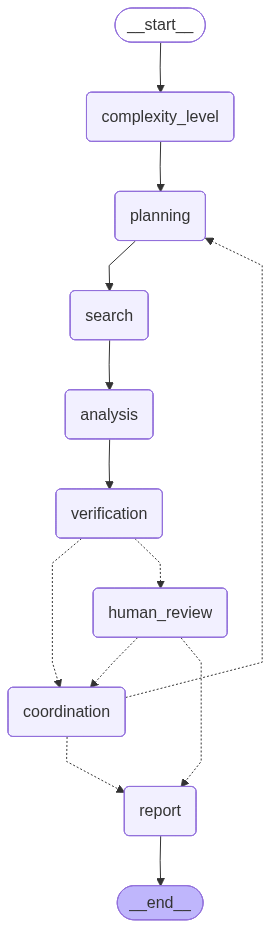

In [18]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 7단계: 테스트 예제

자율 연구 시스템을 실행해봅니다.


### 연구 주제 설정


In [19]:
research_topic = "LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례"

print(f"연구 주제: {research_topic}")


연구 주제: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례


### 자율 연구 실행

주의: Human-in-the-loop 단계에서 사용자 입력이 필요합니다.


In [20]:
print("=" * 80)
print("자율 연구 시스템 시작")
print("=" * 80)

# 초기 상태
initial_state = {
    "topic": research_topic,
    "research_plan": "",
    "search_results": [],
    "analysis_results": [],
    "verification_status": "",
    "verification_feedback": "",
    "needs_more_research": False,
    "iteration_count": 0,
    "max_iterations": 0,  
    "human_approval": True,
    "final_report": ""
}

# 그래프 실행
# 주의: input()이 호출되므로 실제 실행 시 사용자 입력 필요
result = app.invoke(initial_state)

print("\n" + "=" * 80)
print("연구 완료!")
print("=" * 80)


자율 연구 시스템 시작
[주제의 복잡도 에이전트] 주제 복잡도: 복잡 (최대 4회 반복)
[계획 에이전트] 연구 계획 수립 완료 (반복 1회 / 최대 4회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례
[검색 에이전트] 실제 웹 검색 완료 (7개 결과)
[분석 에이전트] 데이터 분석 완료
[검증 에이전트] 추가 조사 필요

[Human-in-the-loop] 사용자 검토 요청
현재 반복: 1/4
검증 상태: needs_more_research

검증 피드백:
STATUS: NEEDS_MORE_RESEARCH

다음은 제시된 분석에 대한 연구 품질 검토와 구체적 피드백입니다.

1) 정보의 충분성 (충분한가?)
- 현재 분석은 고수준의 트렌드와 가능성에 초점을 맞추고 있으며, LangGraph의 구체적 기능, 아키텍처, 인터페이스, 구현 사례에 대한 실증적 근거가 부족합니다.
- 병원 업무 프로세스, 인간 감독의 필요성, 보안/배치 옵션, 플랫폼 간 시너지 등의 아이디어는 제시되나, 구체적 성과 지표(ROI, 처리 지연, 에이전트 간 협업 효율 등)나 실제 도입 사례에 대한 측정치가 없습니다.
- LangGraph와 LangChain 간의 구체적 관계를 명확히 구분하는 근거가 부족하고, 출처 간 맥락 차이가 존재하는 만큼 정보의 일관된 해석을 뒷받침할 구체 자료가 필요합니다.

2) 정보의 신뢰성 (출처가 믿을만한가?)
- 출처가 “출처 1/2/3”로만 제시되어 있어, 실제 원문이나 링크, 버전 정보 등을 확인할 수 없습니다. 따라서 재현 가능성과 신뢰성을 독립적으로 검증하기 어렵습니다.
- 언급된 Vertex AI/Bedrock 같은 신뢰 가능한 플랫폼은 사실상 일반 기술 맥락에서 확인 가능하지만, LangGraph의 구체적 기능과의 직접적 연계성은 확인이 필요합니다.
- 신뢰성을 높이려면 공식 문서(제품 매뉴얼/백서/API 문서), 벤더 발표 자료, 독립적인 벤치마크 연구, 실제 도입 사

### 최종 보고서 확인


In [21]:
print("\n" + "=" * 80)
print("최종 연구 보고서")
print("=" * 80)
print(f"\n총 반복 횟수: {result['iteration_count']}")
print(f"검증 상태: {result['verification_status']}")
print("\n" + "-" * 80)
print(result["final_report"])
print("-" * 80)



최종 연구 보고서

총 반복 횟수: 2
검증 상태: needs_more_research

--------------------------------------------------------------------------------
최종 보고서
주제: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례

1. Executive Summary
- 목적과 범위: 본 보고서는 LangGraph를 중심으로 다중 에이전트 시스템(MAS)의 설계, 운영, 보안·규정 준수 관점에서의 장단점을 체계적으로 분석하고, 의료 분야를 포함한 실제 활용 사례를 정리하여 향후 연구·실무에 대한 가이드라인을 제시합니다.
- 핵심 발견:
  - 장점: 도메인 특화 워크플로우 설계가 가능하고, 인간-in-the-loop를 통한 안전성 확보, 의사결정 규칙의 자동 제어 및 롤백 기능 등으로 규정 준수와 재현성을 강화합니다. 또한 Vertex AI, Bedrock 등 대형 플랫폼과의 병행 운용으로 협력형/분업형 에이전트 구성이 가능해 보안성과 확장성을 높일 여지가 있습니다.
  - 한계점/리스크: 공개적으로 접근 가능한 구체적 기술 사양(API 포맷, 이벤트 흐름, 상태 머신 설계 등)과 실증 지표(ROI, 지연 시간, 재작업 비용 등)에 대한 수치가 제한적입니다. LangGraph와 LangChain 간의 직관적 관계성이나 상호운용성에 대한 명확한 근거가 부족합니다. 또한 의료정보와 같은 민감 데이터의 보안·규정 준수 이슈가 중요합니다.
  - 실무 적용 시 제언: 엄격한 데이터 보안·프라이버시 설계, 온프렘/클라우드 배치 결정에 따른 운영 비용과 보안 제약의 비교, 인간-in-the-loop의 개입 포인트 정의, 모델/데이터 흐름의 감사 로그 및 거버넌스 체계 수립이 필수적입니다.
- 실무적 시사점: 병원 차트 분석, 위험 신호 탐지, 의료진 간 정보 공유 자동화, 병원 운영 대시보드 제공 등의 구체적 활용이 제시되며, 대기업급 플랫폼과의 인터페이스를 통해

### 연구 과정 추적


In [22]:
print("\n" + "=" * 80)
print("연구 과정 추적")
print("=" * 80)

print(f"\n[검색 결과 수집]: {len(result['search_results'])}회")
for i, search in enumerate(result['search_results'], 1):
    print(f"\n--- 검색 {i} ---")
    print(search[:200] + "..." if len(search) > 200 else search)

print(f"\n\n[분석 수행]: {len(result['analysis_results'])}회")
for i, analysis in enumerate(result['analysis_results'], 1):
    print(f"\n--- 분석 {i} ---")
    print(analysis[:200] + "..." if len(analysis) > 200 else analysis)



연구 과정 추적

[검색 결과 수집]: 2회

--- 검색 1 ---

    [실제 웹 검색 결과 - 반복 1]

    다음은 주어진 검색 결과를 바탕으로 LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례를 요약하고 분석한 내용입니다.

1) 출처별 주요 내용 요약

- 출처 1 (premium.naver.com)
  - LangGraph 개요: 병원 업무 프로세스를 단계별로 설계·제어하는...

--- 검색 2 ---

    [실제 웹 검색 결과 - 반복 2]

    다음은 제공된 검색 결과를 바탕으로 한 요약 및 분석입니다.

1) 출처별 요약

- 출처 1 (NAVER 프리미엄 콘텐츠)
  - 주된 내용: LangGraph는 병원 업무 프로세스를 단계별로 설계하고 제어할 수 있는 AI 워크플로우 엔진으로 설명됩니다. 병원 특유의 절차와 승인 과정을 정확히 반영할 ...


[분석 수행]: 2회

--- 분석 1 ---
[분석 결과 - 반복 1]
다음은 주어진 검색 결과를 바탕으로 LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실무 활용 가능성을 비판적으로 분석한 내용입니다.

1) 핵심 패턴과 트렌드 파악
- 도메인 특화 워크플로우의 필요성 증가
  - 병원과 같이 절차·승인 체계가 강하게 작동하는 도메인에서, 도메인 특화 워크플로우 엔진은 각 단계의...

--- 분석 2 ---
[분석 결과 - 반복 2]
다음은 주어진 검색 결과를 바탕으로 LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례를 분석한 정리입니다. 핵심 포인트를 먼저 제시하고, 그다음에 상세한 분석 포인트와 실무 적용 가이드를 제공합니다.

1) 핵심 패턴과 트렌드 파악
- 도메인 특화 워크플로우의 필요성 강조
  - LangGraph는...
